# Model Training and Evaluation

This notebook covers preprocessing, model training, evaluation metrics, and model selection for the fraud detection pipeline.

In [7]:
import json
import os
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from xgboost import XGBClassifier

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / "data" / "raw" / "credit_card_fraud.xlsx"
MODEL_DIR = ROOT_DIR / "models"
MLFLOW_DIR = ROOT_DIR / "mlruns"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)
df["Class"] = df["Class"].astype(int)
df["Amount_log"] = np.log1p(df["Amount"])
feature_columns = [col for col in df.columns if col not in ["Class", "Amount"]]

X = df[feature_columns]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_test))
print("Class imbalance ratio:", int((y_train == 0).sum() / (y_train == 1).sum()))
print("Log-transformed Amount skew:", X_train["Amount_log"].skew())
X_train.head()


Training samples: 227845
Validation samples: 56962
Class imbalance ratio: 577
Log-transformed Amount skew: 0.16039271158291982


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,2.118662
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,1.383791
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,5.171052
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,1.960095
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,4.467057


In [2]:
preprocessor = Pipeline([('scaler', StandardScaler())])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())

candidates = {
    'logistic_regression': (
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        {'C': [0.01, 0.1, 1.0]},
    ),
    'random_forest': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
        {'max_depth': [8, 12, None], 'min_samples_split': [2, 5]},
    ),
    'xgboost': (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    ),
}

results = {}
splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for name, (estimator, params) in candidates.items():
    grid = GridSearchCV(estimator, params, scoring='average_precision', cv=splitter, n_jobs=-1, verbose=0)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model': best_model,
        'best_params': grid.best_params_,
        'classification_report': classification_report(y_test, y_pred, output_dict=True),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
    }

results


c:\Users\P52\anaconda3\envs\PROGDOCTOR\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:52:17] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


{'logistic_regression': {'model': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
  'best_params': {'C': 1.0},
  'classification_report': {'0': {'precision': 0.9998556008808346,
    'recall': 0.974148846370287,
    'f1-score': 0.9868348386866905,
    'support': 56864.0},
   '1': {'precision': 0.057692307692307696,
    'recall': 0.9183673469387755,
    'f1-score': 0.10856453558504221,
    'support': 98.0},
   'accuracy': 0.9740528773568344,
   'macro avg': {'precision': 0.5287739542865711,
    'recall': 0.9462580966545313,
    'f1-score': 0.5476996871358664,
    'support': 56962.0},
   'weighted avg': {'precision': 0.9982346605568909,
    'recall': 0.9740528773568344,
    'f1-score': 0.985323822751436,
    'support': 56962.0}},
  'roc_auc': 0.9704787936558978,
  'pr_auc': 0.7078097995243521},
 'random_forest': {'model': RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                         n_estimators=200, n_jobs=-1, random_state=42),

In [3]:
best_model_name = max(results, key=lambda k: results[k]['pr_auc'])
best_entry = results[best_model_name]
best_model = best_entry['model']

print(f'Best model: {best_model_name}')
print('Best params:', best_entry['best_params'])
print(f"PR-AUC: {best_entry['pr_auc']:.4f}")
print(f"ROC-AUC: {best_entry['roc_auc']:.4f}")

mlflow.set_tracking_uri(MLFLOW_DIR.resolve().as_uri())
mlflow.set_experiment('credit_card_fraud')
with mlflow.start_run(run_name='notebook_model_training') as run:
    mlflow.log_param('training_samples', len(X_train))
    mlflow.log_param('validation_samples', len(X_test))
    mlflow.log_param('feature_count', X_train.shape[1])
    mlflow.log_param('best_model_name', best_model_name)
    mlflow.log_param('amount_skew_after_log1p', float(X_train['Amount_log'].skew()))
    mlflow.log_param('class_imbalance_ratio', int((y_train == 0).sum() / (y_train == 1).sum()))
    mlflow.log_params(best_entry['best_params'])
    mlflow.log_metric('best_pr_auc', best_entry['pr_auc'])
    mlflow.log_metric('best_roc_auc', best_entry['roc_auc'])
    mlflow.log_text(json.dumps(best_entry['classification_report'], indent=2), 'classification_report.json')

    preprocessor_path = MODEL_DIR / 'preprocessor.pkl'
    joblib.dump(preprocessor, preprocessor_path)
    mlflow.log_artifact(str(preprocessor_path))

    try:
        mlflow.sklearn.log_model(
            best_model,
            'model',
            registered_model_name='credit_card_fraud_best_model',
        )
        print('Registered the best model in MLflow Model Registry.')
    except Exception as exc:
        mlflow.sklearn.log_model(best_model, 'model')
        print('Logged the best model artifact, but registry registration failed:', exc)

    print('MLflow run id:', run.info.run_id)


c:\Users\P52\anaconda3\envs\PROGDOCTOR\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/06 19:52:26 INFO mlflow.tracking.fluent: Experiment with name 'credit_card_fraud' does not exist. Creating a new experiment.


Best model: xgboost
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
PR-AUC: 0.8731
ROC-AUC: 0.9771


2026/06/06 19:52:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 19:52:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered the best model in MLflow Model Registry.
MLflow run id: 669c79cb0c2f4e13bae96a22e1f85de2


c:\Users\P52\anaconda3\envs\PROGDOCTOR\Lib\site-packages\mlflow\tracking\_model_registry\utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'credit_card_fraud_best_model'.
Created version '1' of model 'credit_card_fraud_best_model'.


C:\Users\P52\AppData\Local\Temp\ipykernel_22540\4172947900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')


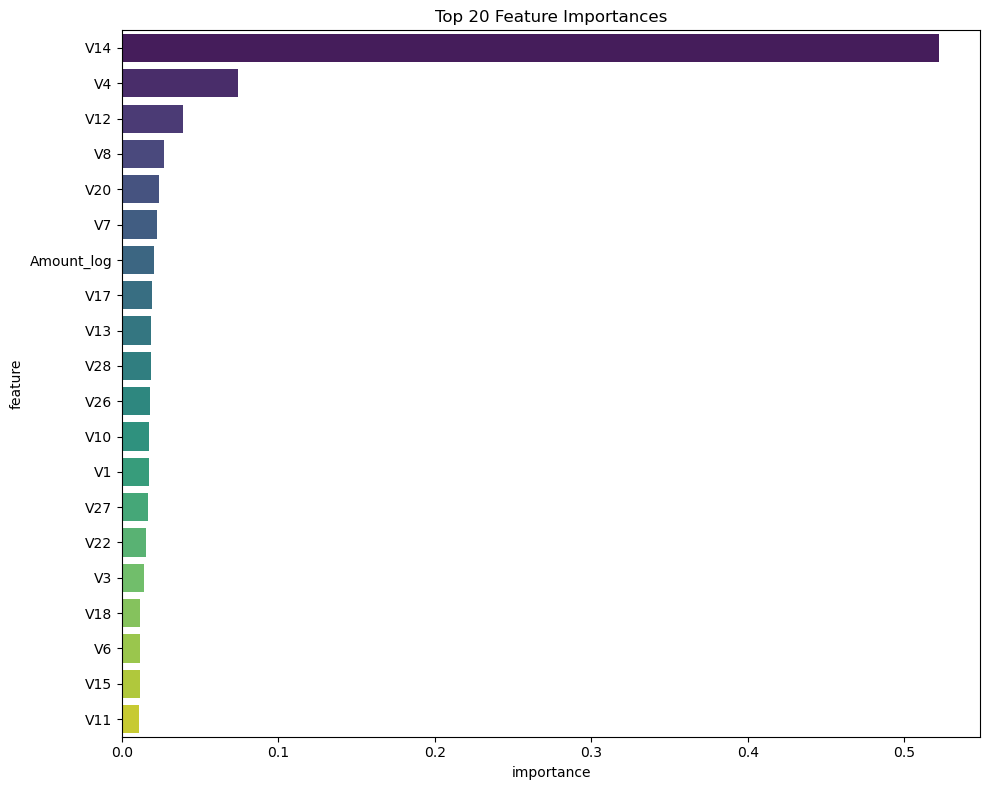

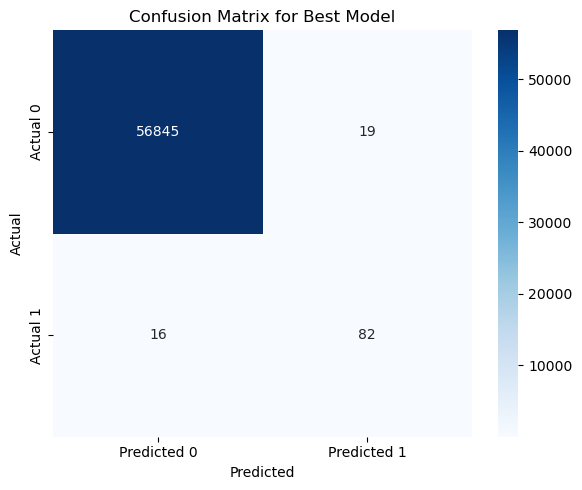

,feature,importance
13,V14,0.522336
3,V4,0.074208
11,V12,0.038770
7,V8,0.026950
19,V20,0.023684
6,V7,0.022531
28,Amount_log,0.020291
16,V17,0.019315
12,V13,0.018668
27,V28,0.018511


In [8]:
# Feature importance and confusion matrix for the selected best model
importance = best_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importance,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

importance_df.head(20)


In [4]:
best_model_path = MODEL_DIR / f'best_model_{best_model_name}.pkl'
joblib.dump(best_model, best_model_path)
print(f'Saved best model locally: {best_model_path}')

metrics_path = MODEL_DIR / 'best_model_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as metrics_file:
    json.dump({
        'best_model_name': best_model_name,
        'best_params': best_entry['best_params'],
        'pr_auc': best_entry['pr_auc'],
        'roc_auc': best_entry['roc_auc'],
    }, metrics_file, indent=2)
print(f'Saved model metrics locally: {metrics_path}')


Saved best model locally: c:\Users\P52\Documents\Projects\CreditCard Fraud\fraud-detection-platform\models\best_model_xgboost.pkl
Saved model metrics locally: c:\Users\P52\Documents\Projects\CreditCard Fraud\fraud-detection-platform\models\best_model_metrics.json


In [11]:
# Create a table of predictions and save as predictions.csv
predictions_proba = best_model.predict_proba(X_test_scaled)[:, 1]
predictions_label = best_model.predict(X_test_scaled).astype(int)

predictions_df = pd.DataFrame({
    'transaction_id': np.arange(1, len(X_test) + 1),
    'amount': df.loc[X_test.index, 'Amount'].reset_index(drop=True),
    'fraud_probability': predictions_proba,
    'prediction': predictions_label,
    'actual': y_test.reset_index(drop=True).astype(int),
})

dashboard_data_dir = ROOT_DIR / 'tableau' / 'dashboard_data'
dashboard_data_dir.mkdir(parents=True, exist_ok=True)
predictions_csv_path = dashboard_data_dir / 'predictions.csv'
predictions_df.to_csv(predictions_csv_path, index=False)
print(f'Saved predictions table to: {predictions_csv_path}')

# Enrich predictions.csv with human-readable labels and risk category
predictions_enriched_df = predictions_df.copy()
predictions_enriched_df['prediction_label'] = predictions_enriched_df['prediction'].map({
    0: 'Legitimate',
    1: 'Fraud',
})
predictions_enriched_df['actual_label'] = predictions_enriched_df['actual'].map({
    0: 'Legitimate',
    1: 'Fraud',
})
predictions_enriched_df['risk_category'] = pd.cut(
    predictions_enriched_df['fraud_probability'],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=['Low', 'Medium', 'High', 'Critical'],
)
predictions_enriched_csv_path = dashboard_data_dir / 'predictions_enriched.csv'
predictions_enriched_df.to_csv(predictions_enriched_csv_path, index=False)
print(f'Saved enriched predictions table to: {predictions_enriched_csv_path}')
predictions_enriched_df.head()

Saved predictions table to: c:\Users\P52\Documents\Projects\CreditCard Fraud\fraud-detection-platform\tableau\dashboard_data\predictions.csv
Saved enriched predictions table to: c:\Users\P52\Documents\Projects\CreditCard Fraud\fraud-detection-platform\tableau\dashboard_data\predictions_enriched.csv


,transaction_id,amount,fraud_probability,prediction,actual,prediction_label,actual_label,risk_category
0,1,23.00,0.000005,0,0,Legitimate,Legitimate,Low
1,2,11.85,0.000019,0,0,Legitimate,Legitimate,Low
2,3,76.07,0.000167,0,0,Legitimate,Legitimate,Low
3,4,0.99,0.000005,0,0,Legitimate,Legitimate,Low
4,5,1.50,0.000615,0,0,Legitimate,Legitimate,Low
